In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# load the dataset 

subscribers_data = pd.read_excel('data/sessions/sessions_subscribers.xlsx' , sheet_name='subscribers' , engine='calamine')
user_session_data = pd.read_excel('data/sessions/sessions_subscribers.xlsx' , sheet_name='user_sessions_sample' , engine='calamine')

In [4]:
# describe the dataset

subscribers_data.head(5)

,user_idx,imsi,msisdn,category,TER_TYPE_NAME_EN,supports_5g,imei,device_tac,TER_BRAND_NAME,TER_MODEL_NAME,TER_SHORT_MODEL,is_national_roaming,usage_percentile,daily_data_mb_baseline,home_site_id,is_fixed
0,0,602017452637550,201526468651,CPE,Dongle,True,867045039420290,86704503,Chengdu Shang-Life Network Technology Company ...,cheyuxing,cheyuxing,0,80.425201,5238.686093,Site_0001,True
1,1,602013703524796,201041106745,Smartphone,Handheld,True,862081048162333,86208104,Shenzhen Kechaoda Technologies Co Ltd,A29,A29,0,27.521218,2067.981493,Site_0002,False
2,2,602019758642524,201080209350,Wearable,Wearable,False,359519752084712,35951975,Freeus LLC,Belle M ATT,Belle,0,40.506563,16599.270947,Site_0001,False
3,3,602016712878817,201065389213,Tablet,e-Book,True,352189052942368,35218905,BlackBerry Limited,Blackberry 9320,Blackberry,0,21.204316,3916.377438,Site_0003,False
4,4,602017924111345,201090312295,CPE,Dongle,True,353491104553747,35349110,Clata Holding LLC,MIFI Modem,MIFI,0,85.323799,5888.044026,Site_0001,True


In [5]:
user_session_data.head(15)

,session_id,user_idx,timestamp,site_id,cell_id,sector,carrier,technology,band,rat,...,msisdn,imei,device_tac,TER_BRAND_NAME,TER_MODEL_NAME,category,is_at_home,is_national_roaming,qci,user_traffic_mb
0,38384_001,38384,2026-01-01,Site_0004,Site_0004_S2_L21,2,L21,4G,2100,4G,...,201027821392,355209115374998,35520911,Gemalto M2M GmbH,Cinterion EXS62-W,CPE,True,0,8,141.655911
1,38384_002,38384,2026-01-01,Site_0004,Site_0004_S2_L18,2,L18,4G,1800,4G,...,201027821392,355209115374998,35520911,Gemalto M2M GmbH,Cinterion EXS62-W,CPE,True,0,8,26.243455
2,10095_001,10095,2026-01-01,Site_0001,Site_0001_S3_L21,3,L21,4G,2100,4G,...,201276845643,354776097620908,35477609,Electronic Sistems (Alkotel) Ltd,TM-203,Smartphone,True,1,7,12.231823
3,15861_001,15861,2026-01-01,Site_0002,Site_0002_S1_L18,1,L18,4G,1800,4G,...,201073943374,449200407487468,44920040,Nokia Corporation,Nokia 3210,Smartphone,True,0,7,107.048399
4,15861_002,15861,2026-01-01,Site_0002,Site_0002_S1_L18,1,L18,4G,1800,4G,...,201073943374,449200407487468,44920040,Nokia Corporation,Nokia 3210,Smartphone,True,0,7,290.994557
5,11932_001,11932,2026-01-01,Site_0004,Site_0004_S2_L18,2,L18,4G,1800,4G,...,201032006667,355753043340880,35575304,Qianwei International Limited,Sprint D510,Smartphone,True,0,9,20.382327
6,11932_002,11932,2026-01-01,Site_0004,Site_0004_S2_L21,2,L21,4G,2100,4G,...,201032006667,355753043340880,35575304,Qianwei International Limited,Sprint D510,Smartphone,True,0,7,12.540008
7,1991_001,1991,2026-01-01,Site_0002,Site_0002_S3_L21,3,L21,4G,2100,4G,...,201093614440,863525004296717,86352500,Dalian Daxian Pantech Communication Co Ltd,DAXIANF5,Smartphone,True,0,7,43.166113
8,1991_002,1991,2026-01-01,Site_0002,Site_0002_S3_L18,3,L18,4G,1800,4G,...,201093614440,863525004296717,86352500,Dalian Daxian Pantech Communication Co Ltd,DAXIANF5,Smartphone,True,0,7,16.331776
9,34032_001,34032,2026-01-01,Site_0004,Site_0004_S3_L21,3,L21,4G,2100,4G,...,201071216864,869451019335792,86945101,HUAWEI Technologies Co Ltd,HUAWEI HUAWEI U8825D,Smartphone,True,0,8,5.076476


In [6]:
traffic_during_day = user_session_data.groupby('timestamp')['user_traffic_mb'].sum().reset_index()

In [7]:
traffic_during_day.head(5)

,timestamp,user_traffic_mb
0,2026-01-01 00:00:00,2.345246e+06
1,2026-01-01 01:00:00,2.913861e+06
2,2026-01-01 02:00:00,1.657647e+06
3,2026-01-01 03:00:00,2.534074e+06
4,2026-01-01 04:00:00,2.063148e+06


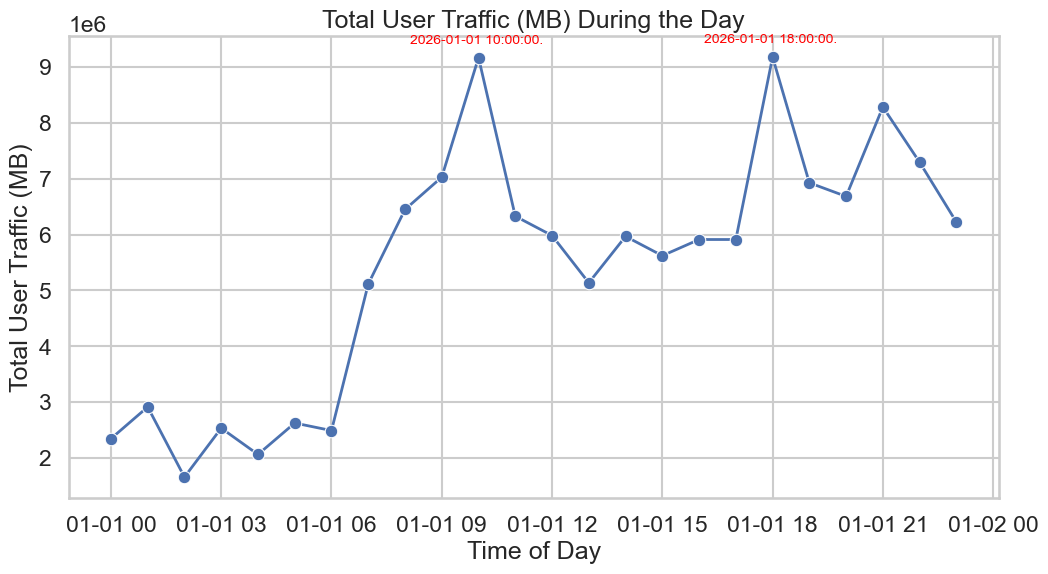

In [8]:
sns.set_theme(style="whitegrid" , context="talk")
plt.figure(figsize=(12, 6))
traffic_during_day['timestamp'] = pd.to_datetime(traffic_during_day['timestamp'])
sns.lineplot(data=traffic_during_day, x='timestamp', y='user_traffic_mb' , marker='o' , linewidth=2)

top_peaks = traffic_during_day.nlargest(2, 'user_traffic_mb')
for _ , row in top_peaks.iterrows():
    plt.annotate(f"{row['timestamp']}. ", 
                 xy=(row['timestamp'], row['user_traffic_mb']), 
                 xytext=(0, 10), 
                 textcoords='offset points', 
                 ha='center', 
                 fontsize=10, 
                 color='red')


plt.title('Total User Traffic (MB) During the Day')
plt.xlabel('Time of Day')
plt.ylabel('Total User Traffic (MB)')
plt.show()

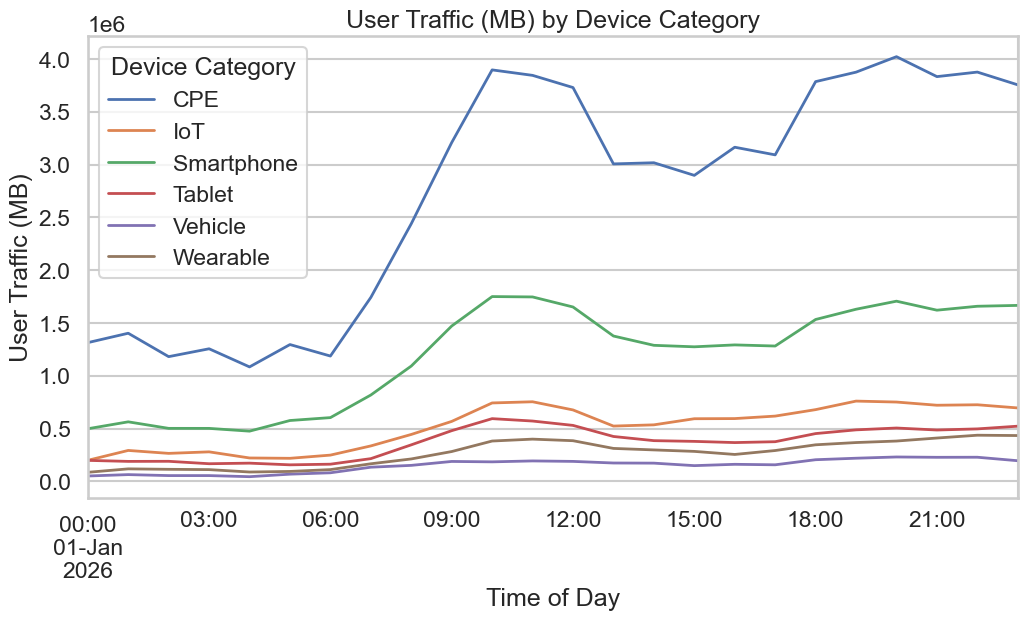

In [9]:
traffic_per_category = user_session_data.groupby(['timestamp', 'category'])['user_traffic_mb'].sum().reset_index()
pivot_traffic_per_category = traffic_per_category.pivot(index='timestamp', columns='category', values='user_traffic_mb').fillna(0)
# trying to smooth it out to see the trends more clearly
window_size = 3

# Apply rolling mean and plot
pivot_traffic_per_category.rolling(window=window_size, min_periods=1).mean().plot(figsize=(12, 6), linewidth=2)

plt.title(f'User Traffic (MB) by Device Category')
plt.xlabel('Time of Day')
plt.ylabel('User Traffic (MB)')
plt.legend(title='Device Category')
plt.show()

C:\Users\Gaming Store\AppData\Local\Temp\ipykernel_17024\3297267876.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=traffic_per_site, x='site_id', y='user_traffic_mb', palette='viridis')


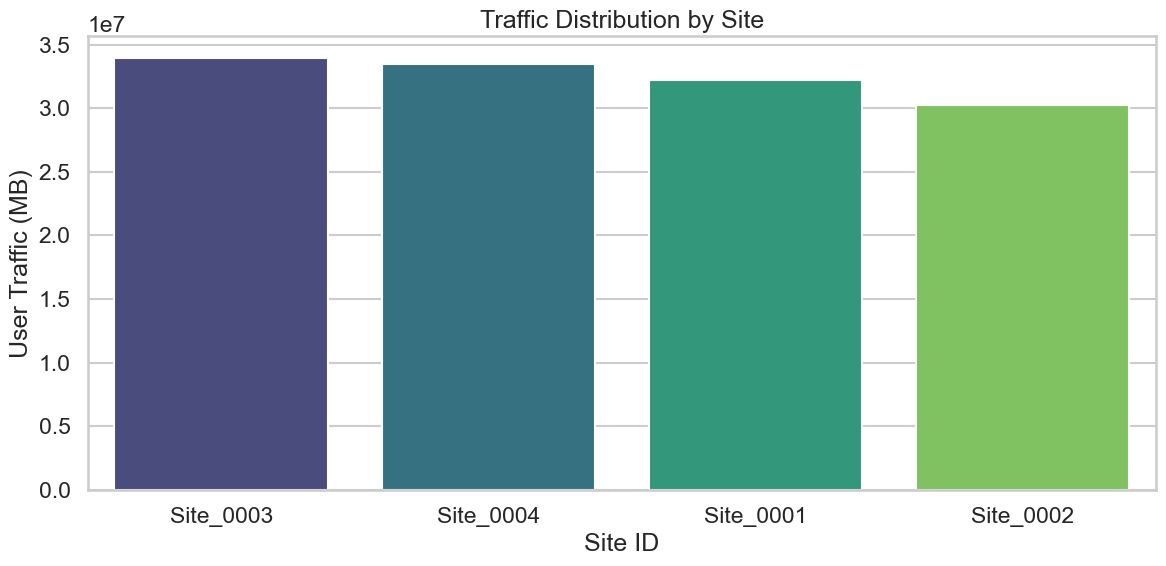

In [10]:
# Q2.  Which sites and sectors carry the most traffic, and which carry the most users? 

traffic_per_site = user_session_data.groupby('site_id')['user_traffic_mb'].sum().reset_index().sort_values(by='user_traffic_mb', ascending=False)

sns.set_theme(style="whitegrid" , context="talk")
plt.figure(figsize=(12, 6))
sns.barplot(data=traffic_per_site, x='site_id', y='user_traffic_mb', palette='viridis')
plt.xlabel('Site ID')
plt.ylabel('User Traffic (MB)')
plt.title('Traffic Distribution by Site')
plt.tight_layout()
plt.show()


In [11]:
user_session_data['sector'].value_counts()

sector
1    284533
2    283710
3    283333
Name: count, dtype: int64

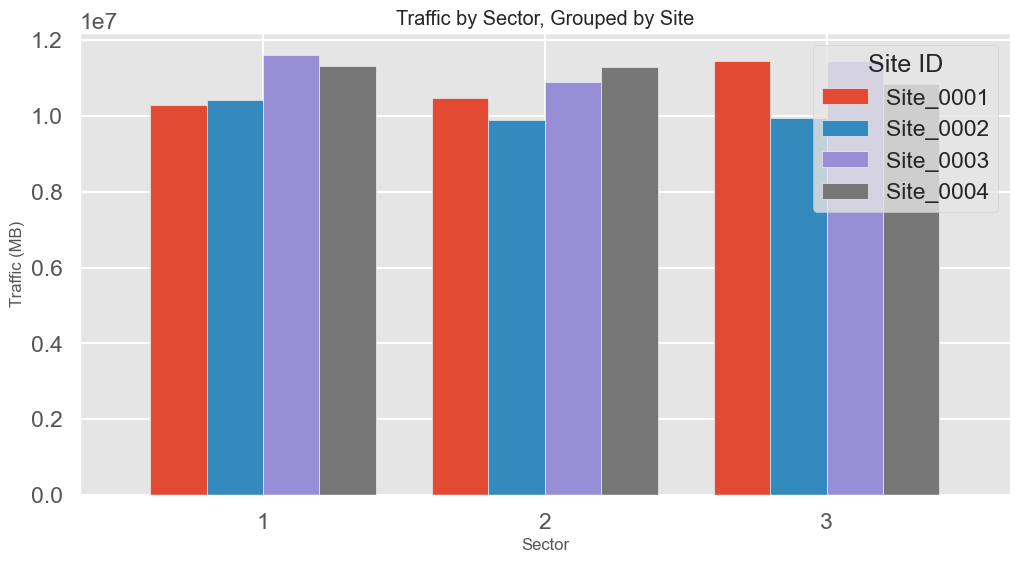

In [12]:
# 1. Create a pivot table 
# Rows will be 'sector', Columns will be 'site_id', and it automatically sums the traffic
pivot_sectors = user_session_data.pivot_table(
    index='sector', 
    columns='site_id', 
    values='user_traffic_mb', 
    aggfunc='sum'
).fillna(0)

# 2. Plot it directly
# Pandas automatically plots columns as grouped bars next to each other
plt.style.use('ggplot')
pivot_sectors.plot(kind='bar', figsize=(12, 6), width=0.8)

plt.title('Traffic by Sector, Grouped by Site')
plt.ylabel('Traffic (MB)')
plt.xlabel('Sector')
plt.legend(title='Site ID')
plt.xticks(rotation=0) # Keeps the sector names flat and readable
plt.show()

C:\Users\Gaming Store\AppData\Local\Temp\ipykernel_17024\1364412795.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=home__offHome_sessions, x='is_at_home', y='user_traffic_mb', palette='Set2')


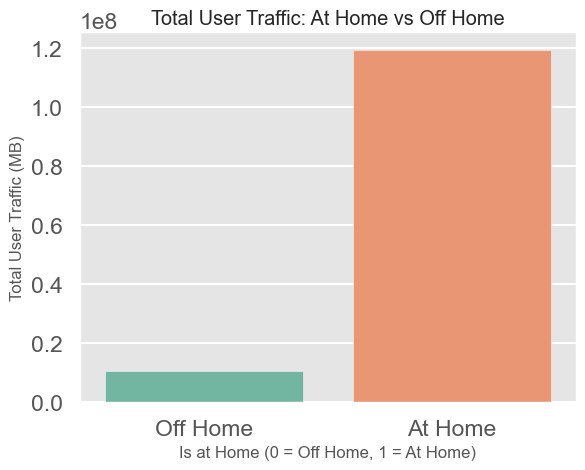

In [ ]:
# Q3.  What fraction of sessions happen away from the user's home site (is_at_home == 0)?
# by my observation first thing is to group the user session sample by is at home

home__offHome_sessions = user_session_data.groupby('is_at_home')['user_traffic_mb'].sum().reset_index()

sns.barplot(data=home__offHome_sessions, x='is_at_home', y='user_traffic_mb', palette='Set2')
plt.xlabel('Is at Home (0 = Off Home, 1 = At Home)')
plt.ylabel('Total User Traffic (MB)')
plt.title('Total User Traffic: At Home vs Off Home')
plt.xticks([0, 1], ['Off Home', 'At Home'])
plt.show()



## # Q4.  Who are the heavy users? 
Define 'heavy user' using daily_data_mb_baseline and usage_percentile. How much of the total 
 session traffic do the top 10% of users generate?

C:\Users\Gaming Store\AppData\Local\Temp\ipykernel_17024\4172288104.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='User Type', title_fontsize=13)


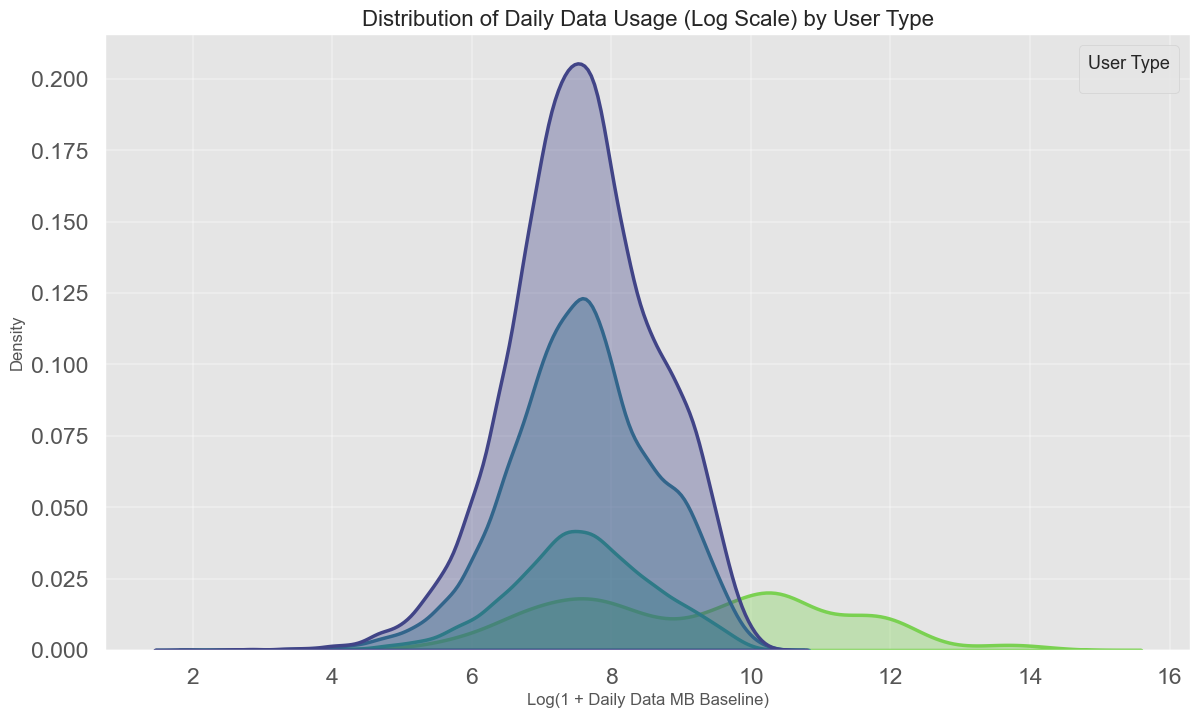

In [ ]:


import matplotlib.pyplot as plt
import numpy as np


subscribers_data['log_daily_data_mb_baseline'] = np.log1p(
    subscribers_data['daily_data_mb_baseline']
)
subscribers_data['user_type'] = np.where(
    subscribers_data['usage_percentile'] >= 90, 'Very Heavy',
    np.where(subscribers_data['usage_percentile'] >= 80, 'Heavy',
    np.where(subscribers_data['usage_percentile'] >= 50, 'Average', 'Light'))
)

plt.figure(figsize=(14, 8))

# Use kdeplot instead of histplot for cleaner overlapping curves
sns.kdeplot(
    data=subscribers_data,
    x='log_daily_data_mb_baseline',
    hue='user_type',
    fill=True,           # shade under the curve
    alpha=0.35,          # transparency so curves don't hide each other
    bw_adjust=1.0,       # smoothness
    palette='viridis',   # good color scheme: Light → Dark
    hue_order=['Light', 'Average', 'Heavy', 'Very Heavy'], 
    linewidth=2.5
)

plt.title('Distribution of Daily Data Usage (Log Scale) by User Type', fontsize=16)
plt.xlabel('Log(1 + Daily Data MB Baseline)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='User Type', title_fontsize=13)
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
# i have this sucpicion that the usage percentile is calculated wrong 
# so i need to invesgative this first 
def calculate_suspicious_percentile(subscribers_data = subscribers_data):
    suspicious_low_percentile_high_usage = subscribers_data[
        (subscribers_data['usage_percentile'] < 50) & 
        (subscribers_data['daily_data_mb_baseline'] > 10000)
    ]
    suspicious_low_percentile_high_usage.head(10)
    print(f"Number of suspicious entries: {len(suspicious_low_percentile_high_usage)}")

In [51]:
# after this suscipsion is confirmed i will need to recalculate the usage percentile and then redo the analysis

subscribers_data['usage_percentile'] = subscribers_data['daily_data_mb_baseline'].rank(method='average', pct=True) * 100
calculate_suspicious_percentile(subscribers_data)

Number of suspicious entries: 0


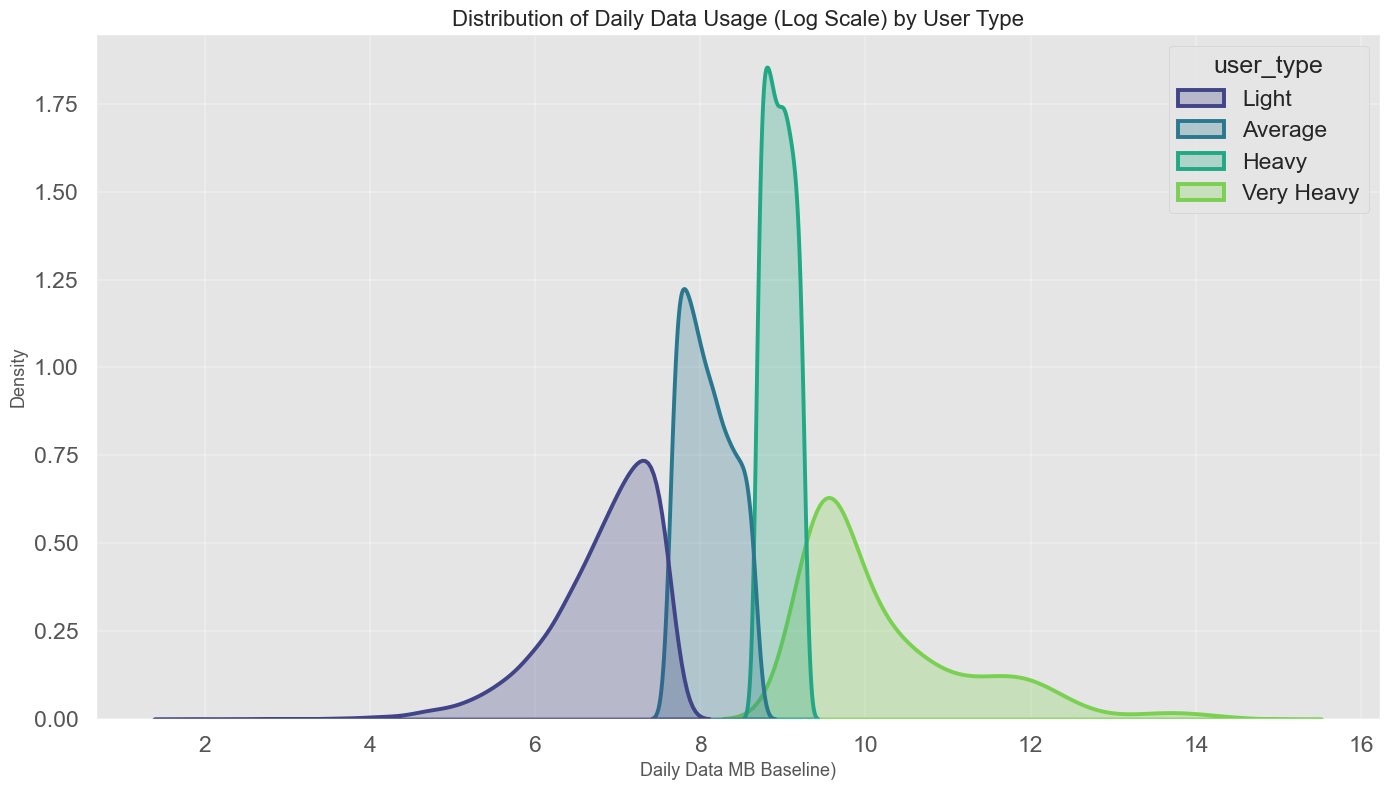

In [58]:
# Log transformation (you already have this)
subscribers_data['log_daily_data_mb_baseline'] = np.log1p(
    subscribers_data['daily_data_mb_baseline']
)

# User type definition (already correct)
subscribers_data['user_type'] = np.where(
    subscribers_data['usage_percentile'] >= 90, 'Very Heavy',
    np.where(subscribers_data['usage_percentile'] >= 80, 'Heavy',
    np.where(subscribers_data['usage_percentile'] >= 50, 'Average', 'Light'))
)

# ==================== IMPROVED PLOT ====================
plt.figure(figsize=(14, 8))

sns.kdeplot(
    data=subscribers_data,
    x='log_daily_data_mb_baseline',
    hue='user_type',
    hue_order=['Light', 'Average', 'Heavy', 'Very Heavy'],
    fill=True,
    alpha=0.28,           # more transparent → better blending
    bw_adjust=1.8,        # much smoother → feels more continuous
    palette='viridis',    # nice continuous-feeling colors
    linewidth=2.8,
    common_norm=False ,
    legend=True
)

plt.title('Distribution of Daily Data Usage (Log Scale) by User Type', fontsize=16)
plt.xlabel('Daily Data MB Baseline)', fontsize=13)
plt.ylabel('Density', fontsize=13)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [61]:
# need to calculate the top 10 percntile 
total_traffic = subscribers_data['daily_data_mb_baseline'].sum()
top_10_percentile_traffic = subscribers_data[subscribers_data['usage_percentile'] >= 90]['daily_data_mb_baseline'].sum()

print(f"Top 10% of users account for {top_10_percentile_traffic / total_traffic:.2%} of total traffic")

Top 10% of users account for 72.84% of total traffic


# Q5.  Is there a relationship between QCI class and traffic volume? 
Which QCI class carries the most total traffic? Do high-priority sessions (QCI 6, 7) behave differently 
from best-effort sessions (QCI 8, 9)? 

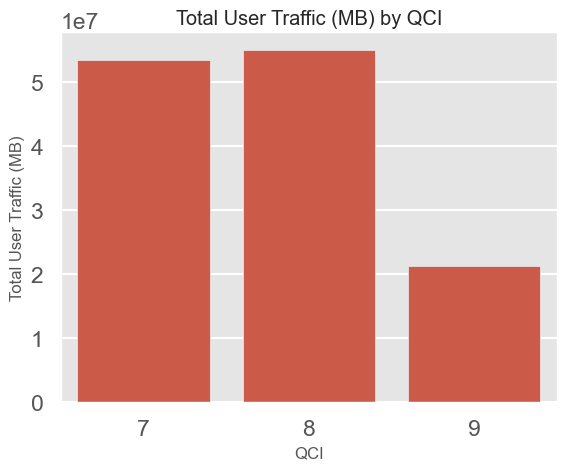

In [ ]:
# now for the last inquiry i need to see the traffic per QCI 

traffic_per_QCI = user_session_data.groupby('qci')['user_traffic_mb'].sum().reset_index().sort_values(by='user_traffic_mb', ascending=False)

sns.barplot(data=traffic_per_QCI, x='qci', y='user_traffic_mb')
plt.xlabel('QCI')
plt.ylabel('Total User Traffic (MB)')
plt.title('Total User Traffic (MB) by QCI')
plt.show()

# i cant seem to answer this question 7 , 8 take the most of traffic there is no QCI 6 
